# Projeto: Análise & Modelagem — Mall Customers (Estruturado)
**Descrição:** Notebook estruturado e didático para o projeto usando *Mall_Customers.csv*.
**Objetivo:** Pipeline completo: carregamento, inspeção, limpeza, EDA, engenharia de features, modelagem, avaliação e conclusões.


## 0) Dependências / Ambiente
Instale: pandas, numpy, matplotlib, seaborn, scikit-learn, imbalanced-learn (quando necessário).

In [1]:
# Importações básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## 1) Carregamento dos dados

In [7]:
# Carregar dados
df = pd.read_csv(r"../Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2) Inspeção inicial
Verificar shape, tipos, valores nulos, duplicatas e estatísticas descritivas.

In [8]:
# Inspeção rápida
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nValores nulos por coluna:')
print(df.isnull().sum())

df.describe(include='all')

Shape: (200, 5)

Dtypes:
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Valores nulos por coluna:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


## 3) Limpeza e Tratamento
- Remover duplicatas
- Tratar nulos
- Ajustar tipos
- Opcional: tratar outliers

In [9]:
# Limpeza exemplo
df = df.drop_duplicates()
# Exemplo de tratamento: preencher nulos ou remover linhas
# df = df.dropna() or df['col'] = df['col'].fillna(valor)
print('Shape após limpeza:', df.shape)
df.isnull().sum()

Shape após limpeza: (200, 5)


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## 4) Análise Exploratória (EDA)
Univariada e bivariada, correlação e visualizações.

In [10]:
# EDA exemplo
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
print('Numéricas:', num_cols)
# Estatísticas
df[num_cols].describe()

Numéricas: ['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 5) Engenharia de Features
Exemplos: normalização, criação de faixas, transformação de variáveis.

In [11]:
# Engenharia de features - exemplo
from sklearn.preprocessing import StandardScaler
if 'Age' in df.columns:
    df['age_group'] = pd.cut(df['Age'], bins=[0,25,35,50,100], labels=['Young','Adult','Mature','Senior'])
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),age_group
0,1,Male,19,15,39,Young
1,2,Male,21,15,81,Young
2,3,Female,20,16,6,Young
3,4,Female,23,16,77,Young
4,5,Female,31,17,40,Adult


## 6) Modelagem — Exemplo: Clustering (KMeans)
Padronizar, determinar k (Elbow/Silhouette), ajustar modelo e interpretar.

In [12]:
# Modelagem - KMeans (exemplo)
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
X = df[num_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
for k in range(1,7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
print('Inertia:', inertia)

# Silhouette para k>=2
from sklearn.metrics import silhouette_score
for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    print(f'k={k}, silhouette=', silhouette_score(X_scaled, labels))

Inertia: [799.9999999999999, 515.6688891233371, 375.38300971453896, 259.69362556823944, 209.5783837699584, 160.9756756881988]
k=2, silhouette= 0.3185134408711024
k=3, silhouette= 0.3371428082096961
k=4, silhouette= 0.4140456252637291
k=5, silhouette= 0.4272395443393026
k=6, silhouette= 0.4390404164555763


## 7) Avaliação e Interpretação
- Visualizar clusters com PCA/t-SNE
- Descrever perfil de cada cluster
- Implicações de negócio

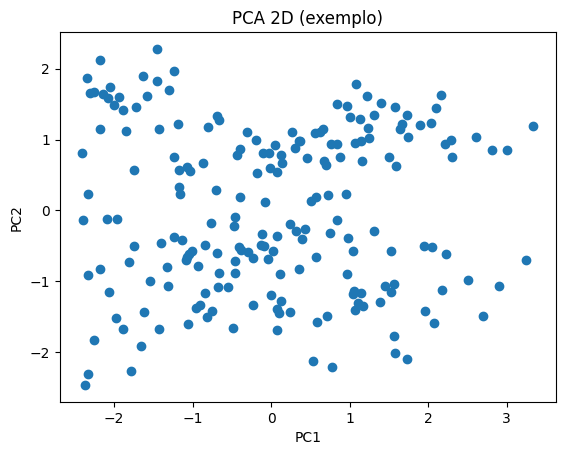

In [13]:
# Interpretação - PCA exemplo
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
import matplotlib.pyplot as plt
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title('PCA 2D (exemplo)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.show()

## 8) Conclusões e Próximos Passos
- Resumo das descobertas
- Testar outros algoritmos, montar pipeline com sklearn.pipeline, validação cruzada, automatizar relatório e gerar README/requirements.txt